<table border=1 width='100%'>
<tr>
<td bgcolor='#0E6251'>

# **<center><font color="#FFFFFF">ML MODEL: DETECCIÓN TEMPRANA DE ANEMIA INFANTIL EN EL PERÚ</font></center>**

</td>
</tr>
</table>

# **1. Carga de Datos y Preprocesamiento Inicial**

## Introducción y Contexto del Proyecto
La anemia infantil constituye una de las deficiencias nutricionales más críticas y de mayor prioridad en la agenda de salud pública en el Perú, afectando el desarrollo cognitivo, motor y psicomotor de los niños en sus etapas más vulnerables. Tradicionalmente, el diagnóstico médico ha tenido un carácter reactivo, supeditado a pruebas invasivas de medición de hemoglobina en sangre.

Con el propósito de cambiar este paradigma hacia un enfoque preventivo y predictivo, este proyecto implementa y compara modelos de aprendizaje automático (Machine Learning) para la detección temprana del riesgo de anemia en niños peruanos de 6 a 59 meses. Utilizando como insumo la Encuesta Demográfica y de Salud Familiar (ENDES 2023), este estudio evalúa enfoques probabilísticos (Regresión Logística), por similitud (K-Nearest Neighbors), jerárquicos (Árboles de Clasificación) y técnicas avanzadas de ensamble (Random Forest y XGBoost), buscando identificar de manera oportuna los factores de riesgo sociodemográficos, antropométricos y de vivienda más influyentes.

## **1.1 Presentación del Diccionario de Datos**
Para el desarrollo del modelo predictivo, se ha consolidado un conjunto de datos multidimensional estructurado en cinco categorías esenciales, omitiendo deliberadamente las métricas directas de laboratorio para evitar el sobreajuste por fuga de datos (*data leakage*):

1. **Variables Biométricas y de Salud:** `EDAD_NINO_MESES`, `PESO_NINO_KG`, `TALLA_NINO_CM`, `DIA_NACIMIENTO`.
2. **Índices Antropométricos (Puntajes Z):** `Z_SCORE_TALLA_EDAD`, `Z_SCORE_PESO_EDAD`, `Z_SCORE_PESO_TALLA`, `Z_SCORE_IMC`.
3. **Variables Sociodemográficas del Hogar:** `SEXO_JEFE_HOGAR`, `EDUCACION_JEFE`, `INDICE_RIQUEZA`, `REGION_NATURAL`.
4. **Variables de Condiciones de Vivienda y Salubridad:** `FUENTE_AGUA`, `TIPO_BANO`, `MATERIAL_PISO`, `MATERIAL_PAREDES`.
5. **Variable Objetivo (Target):** `DIAGNOSTICO_ANEMIA` (Clase binaria: "Con Anemia" / "Sin Anemia").


## **1.2 Diccionario de Datos (Data Dictionary)**

A continuación, se detallan las variables disponibles en el dataset analizado.

<table style="width: 100%; border-collapse: collapse; font-family: Arial, sans-serif; font-size: 14px;">
  <thead>
    <tr style="background-color: #F4F6F6; border-bottom: 3px solid #0E6251;">
      <th style="padding: 15px 12px; text-align: left; font-weight: bold; color: #1A252C; width: 20%;">Variable</th>
      <th style="padding: 15px 12px; text-align: left; font-weight: bold; color: #1A252C; width: 12%;">Tipo de Dato</th>
      <th style="padding: 15px 12px; text-align: left; font-weight: bold; color: #1A252C; width: 12%;">Naturaleza</th>
      <th style="padding: 15px 12px; text-align: left; font-weight: bold; color: #1A252C; width: 56%;">Descripción / Valores Detectados</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>EDAD_NINO_MESES</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Entero</td>
      <td style="padding: 18px 12px;">Edad cronológica del menor expresada en meses.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>PESO_NINO_KG</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Continuo</td>
      <td style="padding: 18px 12px;">Peso corporal del infante medido en kilogramos (kg).</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>TALLA_NINO_CM</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Continuo</td>
      <td style="padding: 18px 12px;">Estatura o longitud del menor medida en centímetros (cm).</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>DIA_NACIMIENTO</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Entero</td>
      <td style="padding: 18px 12px;">Día del mes correspondiente al nacimiento del niño.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>HEMOGLOBINA_G_DL</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Continuo</td>
      <td style="padding: 18px 12px;">Concentración de hemoglobina en la sangre expresada en gramos por decilitro (g/dL). Variable clave para el diagnóstico clínico.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>Z_SCORE_TALLA_EDAD</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Continuo</td>
      <td style="padding: 18px 12px;">Puntaje Z que evalúa la relación Talla para la Edad en comparación con los patrones de la OMS. Indica desnutrición crónica.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>Z_SCORE_PESO_EDAD</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Continuo</td>
      <td style="padding: 18px 12px;">Puntaje Z que evalúa el Peso para la Edad. Monitorea deficiencias globales de peso.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>Z_SCORE_PESO_TALLA</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Continuo</td>
      <td style="padding: 18px 12px;">Puntaje Z del Peso para la Talla. Identifica desnutrición aguda o sobrepeso.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>Z_SCORE_IMC</code></strong></td>
      <td style="padding: 18px 12px;">Numérico</td>
      <td style="padding: 18px 12px;">Continuo</td>
      <td style="padding: 18px 12px;">Puntaje Z del Índice de Masa Corporal (IMC).</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>SEXO_JEFE_HOGAR</code></strong></td>
      <td style="padding: 18px 12px;">Categórico</td>
      <td style="padding: 18px 12px;">Nominal</td>
      <td style="padding: 18px 12px;">Sexo de la persona que lidera el núcleo familiar: <code>Hombre</code>, <code>Mujer</code>.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>EDUCACION_JEFE</code></strong></td>
      <td style="padding: 18px 12px;">Categórico</td>
      <td style="padding: 18px 12px;">Ordinal</td>
      <td style="padding: 18px 12px;">Grado de instrucción formal alcanzado por el jefe del hogar: <code>Sin educación</code>, <code>Primaria incompleta</code>, <code>Primaria completa</code>, <code>Secundaria incompleta</code>, <code>Secundaria completa</code>, <code>Superior</code>.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>INDICE_RIQUEZA</code></strong></td>
      <td style="padding: 18px 12px;">Categórico</td>
      <td style="padding: 18px 12px;">Ordinal</td>
      <td style="padding: 18px 12px;">Quintil de nivel socioeconómico asignado al hogar: <code>El más pobre</code>, <code>Pobre</code>, <code>Medio</code>, <code>Rico</code>, <code>El más rico</code>.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>REGION_NATURAL</code></strong></td>
      <td style="padding: 18px 12px;">Categórico</td>
      <td style="padding: 18px 12px;">Nominal</td>
      <td style="padding: 18px 12px;">Región geográfica de procedencia del paciente en el Perú: <code>Costa</code>, <code>Sierra</code>, <code>Selva</code>, <code>Lima metropolitana</code>.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>FUENTE_AGUA</code></strong></td>
      <td style="padding: 18px 12px;">Categórico</td>
      <td style="padding: 18px 12px;">Nominal</td>
      <td style="padding: 18px 12px;">Origen del abastecimiento hídrico de la vivienda: <code>Dentro de la vivienda</code>, <code>Agua embotellada</code>, <code>Camión cisterna</code>, <code>Pilón/Grifo público</code>, <code>Pozo</code>, <code>Agua de lluvia</code>, <code>Manantial</code>, <code>Río/acequia</code>.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>TIPO_BANO</code></strong></td>
      <td style="padding: 18px 12px;">Categórico</td>
      <td style="padding: 18px 12px;">Nominal</td>
      <td style="padding: 18px 12px;">Tipo de infraestructura para la disposición de excretas: <code>Dentro de la vivienda</code>, <code>Letrina mejorada</code>, <code>Letrina (pozo ciego)</code>, <code>Sin servicio</code>, <code>Pozo séptico</code>.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>MATERIAL_PISO</code></strong></td>
      <td style="padding: 18px 12px;">Categórico</td>
      <td style="padding: 18px 12px;">Nominal</td>
      <td style="padding: 18px 12px;">Componente principal del suelo de la vivienda: <code>Tierra/arena</code>, <code>Cemento/ladrillo</code>, <code>Losetas/cerámicos</code>, <code>Láminas vinílicas</code>, <code>Parquet/madera</code>.</td>
    </tr>
    <tr style="border-bottom: 1px solid #E5E7E9;">
      <td style="padding: 18px 12px;"><strong><code>MATERIAL_PAREDES</code></strong></td>
      <td style="padding: 18px 12px;">Categórico</td>
      <td style="padding: 18px 12px;">Nominal</td>
      <td style="padding: 18px 12px;">Componente principal de la estructura de muros: <code>Ladrillo/cemento</code>, <code>Adobe/tapia</code>, <code>Tablones/madera</code>, <code>Quincha</code>.</td>
    </tr>
    <tr style="border-bottom: 2px solid #0E6251; background-color: #FBFCFC;">
      <td style="padding: 18px 12px;"><strong><code>DIAGNOSTICO_ANEMIA</code></strong></td>
      <td style="padding: 18px 12px; color: #BA4A00;"><strong>Categórico</strong></td>
      <td style="padding: 18px 12px; color: #BA4A00;"><strong>Binario</strong></td>
      <td style="padding: 18px 12px;"><strong>Variable Objetivo (Target).</strong> Estado final determinado para el niño: <code>Con Anemia</code>, <code>Sin Anemia</code>.</td>
    </tr>
  </tbody>
</table>

## **1.3 Importación de Librerías y Módulos**

In [1]:
# 1. LIBRERÍAS BASE Y VISUALIZACIÓN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Configuración por defecto para los gráficos del proyecto
plt.rcParams['figure.figsize'] = [10, 8]
sns.set_theme(style="whitegrid")

# 2. MODELOS DE APRENDIZAJE AUTOMÁTICO (CLASIFICACIÓN)
from sklearn.linear_model import LogisticRegression   # Regresión Logística
from sklearn.neighbors import KNeighborsClassifier     # K-Nearest Neighbors
from sklearn.tree import DecisionTreeClassifier         # Árboles de Clasificación
from sklearn.ensemble import RandomForestClassifier     # Random Forest (Sugerido por Literatura)
from xgboost import XGBClassifier                      # XGBoost (Gradiente Boosting Avanzado)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 3. PREPROCESAMIENTO, BALANCEO Y VALIDACIÓN
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold     # Validación cruzada preservando la proporción de clases
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE               # Para corrección de desbalanceo de datos

# 4. MÉTRICAS DE EVALUACIÓN DE CLASIFICACIÓN
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             roc_auc_score, RocCurveDisplay)

import warnings
warnings.filterwarnings('ignore')

## **1.4 Lectura del Dataset**

In [2]:
filename = 'dataset_anemia_endes_2023.csv'

In [3]:
# Lectura del conjunto de datos
df_anemia = pd.read_csv(filename)

print(f"Dimensiones del dataset cargado: {df_anemia.shape[0]} registros y {df_anemia.shape[1]} columnas.\n")
df_anemia.head()

Dimensiones del dataset cargado: 16035 registros y 18 columnas.



,EDAD_NINO_MESES,PESO_NINO_KG,TALLA_NINO_CM,DIA_NACIMIENTO,HEMOGLOBINA_G_DL,Z_SCORE_TALLA_EDAD,Z_SCORE_PESO_EDAD,Z_SCORE_PESO_TALLA,Z_SCORE_IMC,SEXO_JEFE_HOGAR,EDUCACION_JEFE,INDICE_RIQUEZA,FUENTE_AGUA,TIPO_BANO,MATERIAL_PISO,MATERIAL_PAREDES,REGION_NATURAL,DIAGNOSTICO_ANEMIA
0,38,16.8,97.5,10,11.4,12.0,115.0,156.0,157.0,Hombre,Secundaria completa,Medio,Dentro de la vivienda,Dentro de la vivienda,Losetas/terrazos/cerámicos,Ladrillo o bloques de cemento,Resto Costa,Sin Anemia
1,53,16.9,104.4,25,12.4,-44.0,-15.0,17.0,19.0,Hombre,Secundaria incompleta,El más rico,Dentro de la vivienda,Dentro de la vivienda,Losetas/terrazos/cerámicos,Ladrillo o bloques de cemento,Resto Costa,Sin Anemia
2,16,11.3,79.5,19,9.4,8.0,102.0,135.0,135.0,Hombre,Secundaria incompleta,Rico,Dentro de la vivienda,Dentro de la vivienda,Cemento/ladrillo,Ladrillo o bloques de cemento,Resto Costa,Con Anemia
3,17,10.4,79.7,26,11.2,-58.0,-28.0,1.0,11.0,Hombre,Secundaria completa,El más rico,Dentro de la vivienda,Dentro de la vivienda,Losetas/terrazos/cerámicos,Ladrillo o bloques de cemento,Resto Costa,Sin Anemia
4,27,11.9,88.9,3,8.9,-40.0,-68.0,-74.0,-69.0,Hombre,Secundaria incompleta,Rico,Agua embotellada,Dentro de la vivienda,Cemento/ladrillo,Ladrillo o bloques de cemento,Resto Costa,Con Anemia


# **2. Análisis Exploratorio y Preprocesamiento de Datos**

## **2.1 Inspección Inicial del Dataset**
Antes de realizar cualquier transformación, es necesario conocer la estructura interna de los datos consolidados. Cabe resaltar que, a nivel de columnas, no se realizará una eliminación masiva de características, puesto que este dataset ya es el resultado de un riguroso proceso de integración y selección previa de los módulos "Características de la Vivienda", "Características del Hogar" y "Peso-Talla y Anemia" de la ENDES 2023.

In [4]:
# Verificación general de datos

In [5]:
print("INFORMACIÓN GENERAL DEL DATASET\n")
df_anemia.info()

INFORMACIÓN GENERAL DEL DATASET

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16035 entries, 0 to 16034
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EDAD_NINO_MESES     16035 non-null  int64  
 1   PESO_NINO_KG        16035 non-null  float64
 2   TALLA_NINO_CM       16035 non-null  float64
 3   DIA_NACIMIENTO      16035 non-null  int64  
 4   HEMOGLOBINA_G_DL    16035 non-null  float64
 5   Z_SCORE_TALLA_EDAD  16035 non-null  float64
 6   Z_SCORE_PESO_EDAD   16035 non-null  float64
 7   Z_SCORE_PESO_TALLA  16035 non-null  float64
 8   Z_SCORE_IMC         16035 non-null  float64
 9   SEXO_JEFE_HOGAR     16035 non-null  object 
 10  EDUCACION_JEFE      16035 non-null  object 
 11  INDICE_RIQUEZA      16035 non-null  object 
 12  FUENTE_AGUA         16035 non-null  object 
 13  TIPO_BANO           16035 non-null  object 
 14  MATERIAL_PISO       16035 non-null  object 
 15  MATERIAL_PAREDES    

In [6]:
print("TIPOS DE DATOS\n")
print(df_anemia.dtypes)

TIPOS DE DATOS

EDAD_NINO_MESES         int64
PESO_NINO_KG          float64
TALLA_NINO_CM         float64
DIA_NACIMIENTO          int64
HEMOGLOBINA_G_DL      float64
Z_SCORE_TALLA_EDAD    float64
Z_SCORE_PESO_EDAD     float64
Z_SCORE_PESO_TALLA    float64
Z_SCORE_IMC           float64
SEXO_JEFE_HOGAR        object
EDUCACION_JEFE         object
INDICE_RIQUEZA         object
FUENTE_AGUA            object
TIPO_BANO              object
MATERIAL_PISO          object
MATERIAL_PAREDES       object
REGION_NATURAL         object
DIAGNOSTICO_ANEMIA     object
dtype: object


In [7]:
print("ESTADÍSTICAS DESCRIPTIVAS\n")
display(df_anemia.describe())

ESTADÍSTICAS DESCRIPTIVAS



,EDAD_NINO_MESES,PESO_NINO_KG,TALLA_NINO_CM,DIA_NACIMIENTO,HEMOGLOBINA_G_DL,Z_SCORE_TALLA_EDAD,Z_SCORE_PESO_EDAD,Z_SCORE_PESO_TALLA,Z_SCORE_IMC
count,16035.000000,16035.000000,16035.000000,16035.000000,16035.000000,16035.000000,16035.000000,16035.000000,16035.000000
mean,32.842095,13.319601,89.082021,15.638853,12.006349,-86.980418,-14.556283,47.040661,56.346118
std,15.840657,3.528144,12.085555,8.745253,1.410104,101.394911,103.386292,99.898358,98.391974
min,6.000000,5.200000,56.600000,1.000000,6.200000,-582.000000,-468.000000,-391.000000,-385.000000
25%,19.000000,10.600000,79.600000,8.000000,11.100000,-154.000000,-83.000000,-18.000000,-7.000000
50%,33.000000,13.200000,90.300000,16.000000,11.900000,-89.000000,-20.000000,43.000000,53.000000
75%,47.000000,15.700000,98.900000,23.000000,12.900000,-21.000000,48.000000,106.000000,114.000000
max,59.000000,33.100000,119.200000,31.000000,17.800000,298.000000,477.000000,493.000000,492.000000


## **2.2 Limpieza, Tratamiento de Nulos y Fuga de Datos**
Un paso crucial para el correcto entrenamiento de nuestros modelos es evitar que utilicen una variable como única determinante para el objetivo. Por ello, se debe eliminar la variable `HEMOGLOBINA_G_DL`, la cual determina directamente el diagnóstico médico. Esta exclusión previene el sobreajuste por fuga de datos (data leakage).
Asimismo, se verificará la existencia de valores nulos o filas duplicadas para imputarlos o descartarlos según corresponda.

In [8]:
# 1. ELIMINACIÓN DE FUGA DE DATOS (DATA LEAKAGE)
if 'HEMOGLOBINA_G_DL' in df_anemia.columns:
    df_anemia = df_anemia.drop('HEMOGLOBINA_G_DL', axis=1)
    print("Variable 'HEMOGLOBINA_G_DL' eliminada exitosamente para prevenir fuga de datos.")

# 2. VERIFICACIÓN Y TRATAMIENTO DE DUPLICADOS
duplicados = df_anemia.duplicated().sum()
print(f"\nCantidad de filas duplicadas encontradas: {duplicados}")
if duplicados > 0:
    df_anemia = df_anemia.drop_duplicates()
    print("Filas duplicadas eliminadas.")

Variable 'HEMOGLOBINA_G_DL' eliminada exitosamente para prevenir fuga de datos.

Cantidad de filas duplicadas encontradas: 0


In [9]:
# 3. VERIFICACIÓN DE NULOS
# Porcentaje de nulos
null_pct = (df_anemia.isna().sum() / len(df_anemia)).sort_values(ascending=False) * 100
print("\\nPorcentaje de nulos por columna (%):")
print(null_pct)

# Imputación básica (Se ejecuta solo si hay nulos)
# Para variables numéricas usamos la mediana (menos sensible a outliers)
# Para variables categóricas usamos la moda
for col in df_anemia.columns:
    if df_anemia[col].isnull().sum() > 0:
        if df_anemia[col].dtype == 'object':
            df_anemia[col].fillna(df_anemia[col].mode()[0], inplace=True)
        else:
            df_anemia[col].fillna(df_anemia[col].median(), inplace=True)

print("\nImputación completada. Nulos actuales:", df_anemia.isnull().sum().sum())

\nPorcentaje de nulos por columna (%):
EDAD_NINO_MESES       0.0
PESO_NINO_KG          0.0
TALLA_NINO_CM         0.0
DIA_NACIMIENTO        0.0
Z_SCORE_TALLA_EDAD    0.0
Z_SCORE_PESO_EDAD     0.0
Z_SCORE_PESO_TALLA    0.0
Z_SCORE_IMC           0.0
SEXO_JEFE_HOGAR       0.0
EDUCACION_JEFE        0.0
INDICE_RIQUEZA        0.0
FUENTE_AGUA           0.0
TIPO_BANO             0.0
MATERIAL_PISO         0.0
MATERIAL_PAREDES      0.0
REGION_NATURAL        0.0
DIAGNOSTICO_ANEMIA    0.0
dtype: float64

Imputación completada. Nulos actuales: 0


## **2.3 Detección de Outliers (Histogramas y Boxplots)**
Mediante la visualización de las distribuciones, verificaremos la existencia de valores atípicos (outliers), especialmente en las variables biométricas y los Z-Scores.

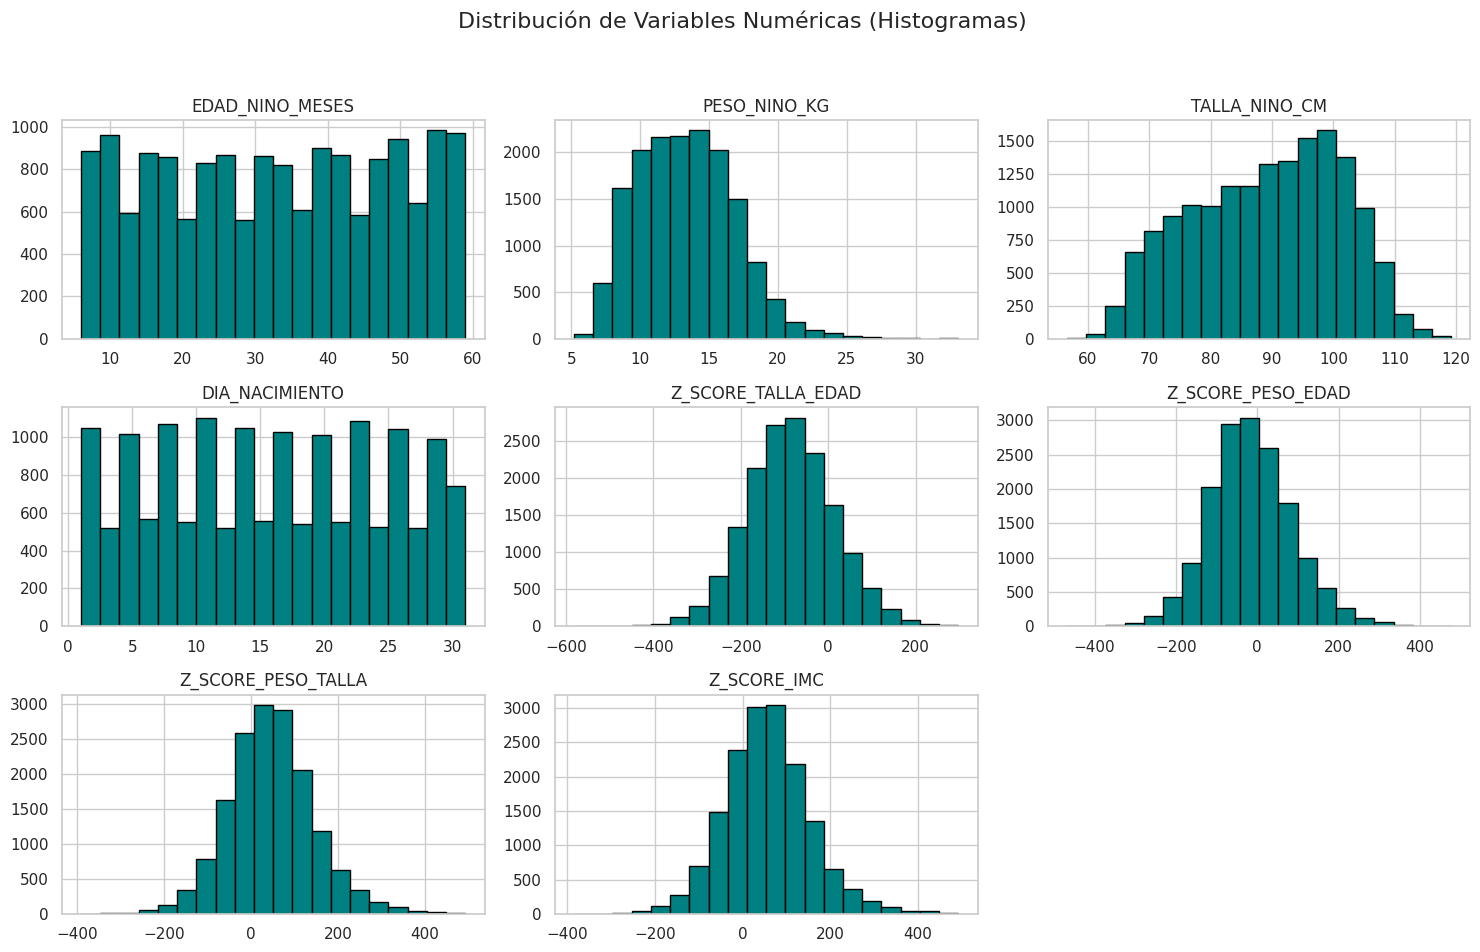

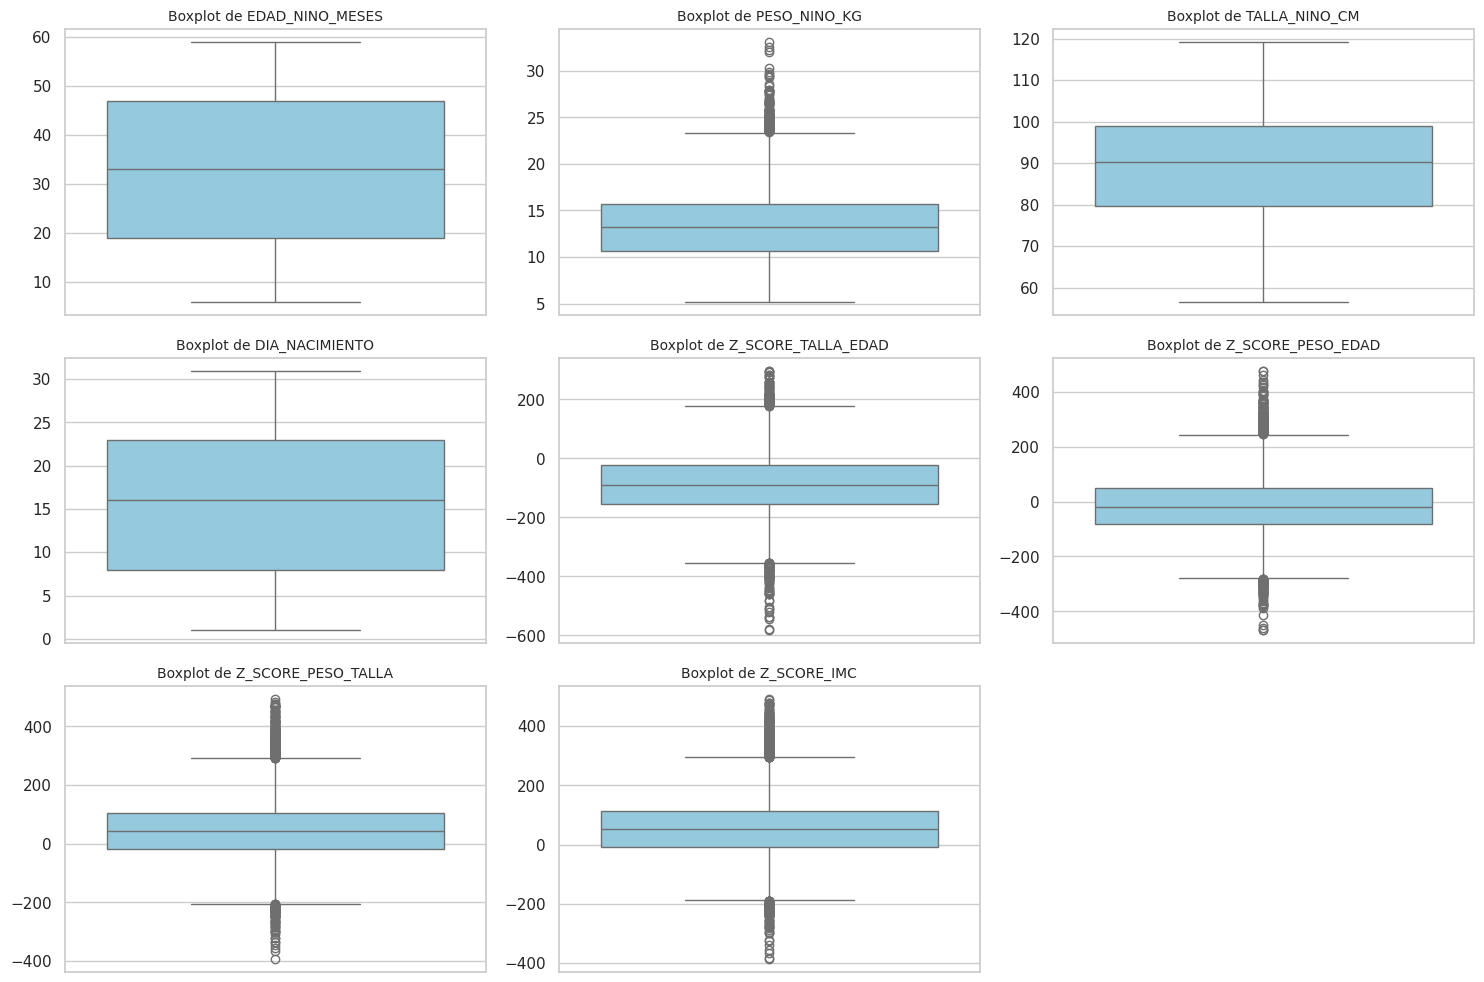

In [10]:
# Separar solo las columnas numéricas para graficar
cols_numericas = df_anemia.select_dtypes(include=[np.number]).columns

# Generar Histogramas
df_anemia[cols_numericas].hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas (Histogramas)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Generar Boxplots para identificar Outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_anemia[col], color='skyblue')
    plt.title(f'Boxplot de {col}', fontsize=10)
    plt.ylabel('')
plt.tight_layout()
plt.show()

## **2.4 Transformación (Encoding) y Escalamiento**
Dado que los algoritmos matemáticos requieren datos numéricos, transformaremos las variables categóricas utilizando codificación ordinal y One-Hot Encoding. Adicionalmente, las variables numéricas serán estandarizadas (StandardScaler) para que modelos como K-NN y Regresión Logística, que son sensibles a la magnitud, operen en una misma escala.

In [11]:
# 1. MAPEO DE LA VARIABLE OBJETIVO (TARGET)
df_anemia['DIAGNOSTICO_ANEMIA'] = df_anemia['DIAGNOSTICO_ANEMIA'].map({'Con Anemia': 1, 'Sin Anemia': 0})

# 2. CODIFICACIÓN ORDINAL (Respeta la jerarquía de la categoría)
mapeo_educacion = {'Sin educación': 0, 'Primaria incompleta': 1, 'Primaria completa': 2,
                   'Secundaria incompleta': 3, 'Secundaria completa': 4, 'Superior': 5}
mapeo_riqueza = {'El más pobre': 0, 'Pobre': 1, 'Medio': 2, 'Rico': 3, 'El más rico': 4}

# Validamos si existen antes de mapear
if 'EDUCACION_JEFE' in df_anemia.columns:
    df_anemia['EDUCACION_JEFE'] = df_anemia['EDUCACION_JEFE'].map(mapeo_educacion)
if 'INDICE_RIQUEZA' in df_anemia.columns:
    df_anemia['INDICE_RIQUEZA'] = df_anemia['INDICE_RIQUEZA'].map(mapeo_riqueza)

# 3. ONE-HOT ENCODING (Para variables nominales sin jerarquía)
cols_nominales = ['SEXO_JEFE_HOGAR', 'REGION_NATURAL', 'FUENTE_AGUA', 'TIPO_BANO', 'MATERIAL_PISO', 'MATERIAL_PAREDES']
df_anemia = pd.get_dummies(df_anemia, columns=cols_nominales, drop_first=True)

print("Transformación y escalamiento completados. Nuevas dimensiones:", df_anemia.shape)

Transformación y escalamiento completados. Nuevas dimensiones: (16035, 50)


## **2.5 Análisis de Correlación**
Tras convertir todo el conjunto a formato numérico, evaluamos las relaciones lineales a través de una Matriz de Correlación. Esto nos permitirá identificar casos de multicolinealidad.

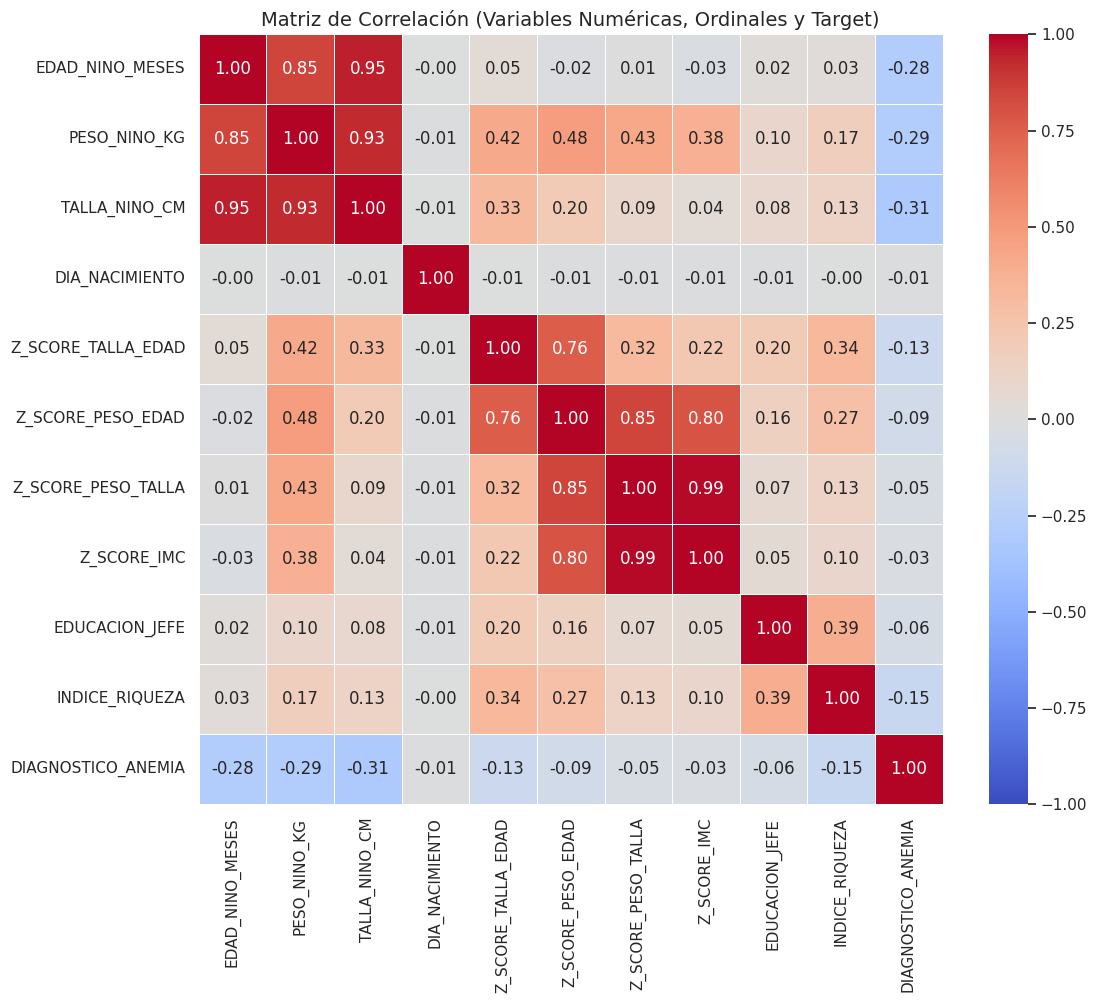

In [12]:
# Seleccionamos las columnas numéricas (excluyendo la que vamos a predecir si estuviera ahí)
cols_a_escalar = cols_numericas.tolist()
cols_correlacion = cols_a_escalar + ['EDUCACION_JEFE', 'INDICE_RIQUEZA', 'DIAGNOSTICO_ANEMIA']

plt.figure(figsize=(12, 10))
matriz_corr = df_anemia[cols_correlacion].corr()
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación (Variables Numéricas, Ordinales y Target)', fontsize=14)
plt.show()

## **2.6 Tratamiento de Multicolinealidad (Remoción de Redundancias)**
Tras analizar la matriz de correlación inicial, se identificó una colinealidad crítica de 0.99 entre `Z_SCORE_IMC` y `Z_SCORE_PESO_TALLA`. Dado que ambos indicadores miden la misma dimensión fisiológica en infantes, se procede a eliminar `Z_SCORE_IMC`, priorizando `Z_SCORE_PESO_TALLA` por ser el estándar epidemiológico internacional de la OMS para medir desnutrición aguda en la primera infancia.

In [13]:
# Eliminación de la variable redundante por alta correlación (0.99)
if 'Z_SCORE_IMC' in df_anemia.columns:
    df_anemia = df_anemia.drop('Z_SCORE_IMC', axis=1)
    print("Variable 'Z_SCORE_IMC' eliminada exitosamente para mitigar la multicolinealidad perfecta.")

# Actualizamos la lista de columnas a escalar y correlacionar para los siguientes pasos
if 'Z_SCORE_IMC' in cols_a_escalar:
    cols_a_escalar.remove('Z_SCORE_IMC')

print("Dimensiones actuales del dataset antes del split:", df_anemia.shape)

Variable 'Z_SCORE_IMC' eliminada exitosamente para mitigar la multicolinealidad perfecta.
Dimensiones actuales del dataset antes del split: (16035, 49)


## **2.7 Matriz de Correlación Actualizada**
Reevaluamos las relaciones lineales en el conjunto de datos tras haber mitigado el problema de multicolinealidad severa.

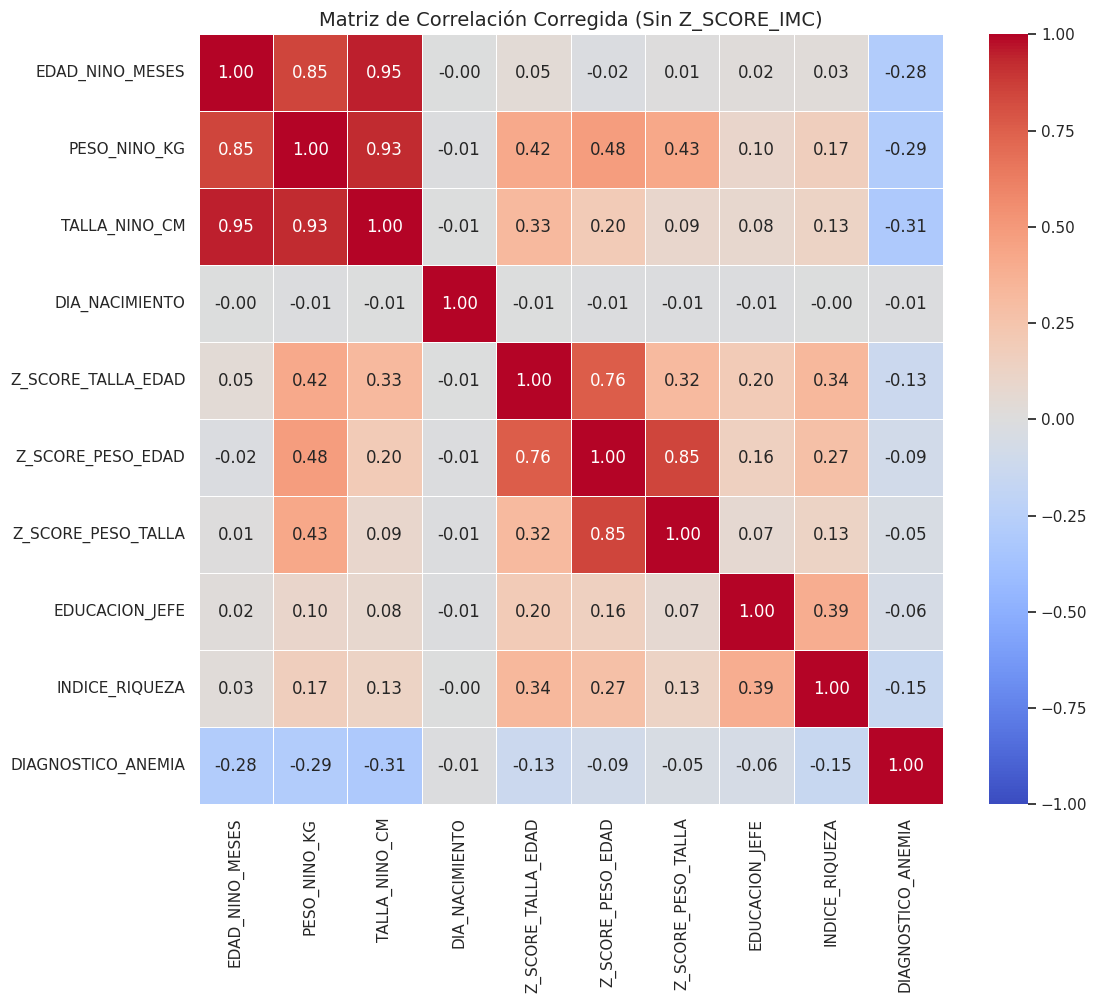

In [14]:
# Configuración de las variables para la nueva matriz de correlación
cols_correlacion_actualizada = cols_a_escalar + ['EDUCACION_JEFE', 'INDICE_RIQUEZA', 'DIAGNOSTICO_ANEMIA']

plt.figure(figsize=(12, 10))
matriz_corr_act = df_anemia[cols_correlacion_actualizada].corr()

# Generar Heatmap Actualizado
sns.heatmap(matriz_corr_act, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación Corregida (Sin Z_SCORE_IMC)', fontsize=14)
plt.show()

## **2.8 Partición de Datos (Train-Test Split) y Balanceo (SMOTE)**

Aquí se aplica la partición 70/30 estratificada. Para asegurar una metodología rigurosa y evitar la fuga de datos (*Data Leakage*), el imputador de nulos y el escalador numérico aprenden (fit) exclusivamente de la data de entrenamiento. Posteriormente se aplica SMOTE solo al bloque de Train.

In [15]:
# 1. SEPARACIÓN EN X (Predictoras) e y (Target)
X = df_anemia.drop('DIAGNOSTICO_ANEMIA', axis=1)
y = df_anemia['DIAGNOSTICO_ANEMIA']

# 2. PARTICIÓN DE DATOS (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# 3. IMPUTACIÓN ROBUSTA (Red de seguridad para NaNs generados durante el Mapeo)
imputer = SimpleImputer(strategy='median')
X_train_cols = X_train.columns

# Aprendemos e imputamos SOLO en Train
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train_cols, index=X_train.index)
# SOLO imputamos en Test (usando la mediana calculada del Train)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train_cols, index=X_test.index)

print("Nulos restantes en Entrenamiento tras imputación:", X_train.isnull().sum().sum())

# 4. ESCALAMIENTO SIN FUGA DE DATOS
scaler = StandardScaler()
# Aprendemos y transformamos SOLO el Train
X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
# SOLO transformamos el Test (usando las reglas aprendidas del Train)
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

print(f"Dimensiones tras Split y Escalamiento -> Train: {X_train.shape}, Test: {X_test.shape}")

# 5. APLICACIÓN DE SMOTE (Solo Entrenamiento)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nDistribución de clases ANTES de SMOTE en Entrenamiento:\n{y_train.value_counts()}")
print(f"\nDistribución de clases DESPUÉS de SMOTE en Entrenamiento:\n{y_train_sm.value_counts()}")

Nulos restantes en Entrenamiento tras imputación: 0
Dimensiones tras Split y Escalamiento -> Train: (11224, 48), Test: (4811, 48)

Distribución de clases ANTES de SMOTE en Entrenamiento:
DIAGNOSTICO_ANEMIA
0    7238
1    3986
Name: count, dtype: int64

Distribución de clases DESPUÉS de SMOTE en Entrenamiento:
DIAGNOSTICO_ANEMIA
0    7238
1    7238
Name: count, dtype: int64


# **3. Setup Experimental y Entrenamiento de Modelos**

En esta sección se define el entorno controlado para la optimización de los hiperparámetros de los cinco algoritmos planteados en la metodología: **Regresión Logística**, **K-Nearest Neighbors (K-NN)**, **Árboles de Clasificación (CART)**, **Random Forest** y **XGBoost**.

*(Nota: Las variables numéricas ya fueron estandarizadas y las categóricas codificadas durante la fase de preprocesamiento, por lo que los conjuntos `X_train_sm` y `X_test` ingresan directamente a la fase de modelado).*

Para garantizar un proceso robusto y mitigar el sobreajuste (*overfitting*), la búsqueda se realiza mediante la técnica de **GridSearchCV** acoplada a una **Validación Cruzada Estratificada de 10 particiones (10-Fold CV)**, aplicada única y exclusivamente sobre el conjunto de entrenamiento balanceado. La métrica de optimización interna utilizada es el `balanced_accuracy`, ideal para evaluar equitativamente el desempeño en problemas de salud pública con desbalance de origen.

# 3.1 Búsqueda de Hiperparámetros mediante GridSerachCV (10-FOLD CV)

In [16]:
# 1. Definición del particionador homogéneo de 10 folds con la semilla del proyecto
seed = 7
kfold = StratifiedKFold(n_splits=10, random_state=seed, shuffle=True)

# 2. Definición del pool de los 5 algoritmos con sus respectivas grillas de hiperparámetros
grids = {
    'LogReg': (
        LogisticRegression(solver='liblinear', random_state=42),
        {'C': [0.1, 1, 10], 'max_iter': [500, 1000]}
    ),
    'K-NN': (
        KNeighborsClassifier(),
        {'n_neighbors': [5, 10, 15], 'weights': ['uniform', 'distance']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
    ),
    'XGBoost': (
        XGBClassifier(random_state=42, eval_metric='logloss'),
        {'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7], 'n_estimators': [50, 100]}
    )
}

# Diccionarios para almacenar los modelos óptimos y los resultados de cada fold
mejores_modelos = {}
resultados_cv_dict = {}

print("EVALUANDO Y OPTIMIZANDO LOS 5 ALGORITMOS EN VALIDACIÓN CRUZADA (10-FOLD-CV)")
print("Métrica de optimización interna: balanced_accuracy\n")

for nombre, (modelo, params) in grids.items():
    start_time = time.time()

    # Configuración de la búsqueda en grilla
    grid_search = GridSearchCV(modelo, params, cv=kfold, scoring='balanced_accuracy', n_jobs=-1)

    # Entrenamiento exclusivo con data de Train balanceada (SMOTE)
    grid_search.fit(X_train_sm, y_train_sm)

    end_time = time.time()
    tiempo_ejecucion = round(end_time - start_time, 2)

    # Almacenamiento del mejor estimador e hiperparámetros óptimos obtenidos
    mejores_modelos[nombre] = {
        'best_estimator': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'tiempo_segundos': tiempo_ejecucion
    }

    # Extracción de los scores de los 10 folds correspondientes a la mejor configuración
    best_idx = grid_search.best_index_
    fold_scores = [grid_search.cv_results_[f'split{i}_test_score'][best_idx] for i in range(10)]
    resultados_cv_dict[nombre] = fold_scores

    print(f"[{nombre}] Optimizado en {tiempo_ejecucion}s. Mejores parámetros: {grid_search.best_params_}")

EVALUANDO Y OPTIMIZANDO LOS 5 ALGORITMOS EN VALIDACIÓN CRUZADA (10-FOLD-CV)
Métrica de optimización interna: balanced_accuracy

[LogReg] Optimizado en 10.4s. Mejores parámetros: {'C': 10, 'max_iter': 500}
[K-NN] Optimizado en 9.16s. Mejores parámetros: {'n_neighbors': 5, 'weights': 'distance'}
[Decision Tree] Optimizado en 9.98s. Mejores parámetros: {'max_depth': 10, 'min_samples_split': 2}
[Random Forest] Optimizado en 68.38s. Mejores parámetros: {'max_depth': None, 'n_estimators': 50}
[XGBoost] Optimizado en 73.86s. Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}


## 3.2. Visualización Gráfica de la Estabilidad en Entrenamiento (Boxplot)

Se presenta un diagrama de cajas y bigotes (*Boxplot*) construido a partir de las métricas obtenidas en cada una de las 10 iteraciones de la validación cruzada. Este gráfico condensa la información visualmente y permite analizar de forma directa la dispersión, consistencia y variabilidad del `balanced_accuracy` de cada algoritmo optimizado, identificando qué enfoques son más estables frente a las variaciones de los datos.

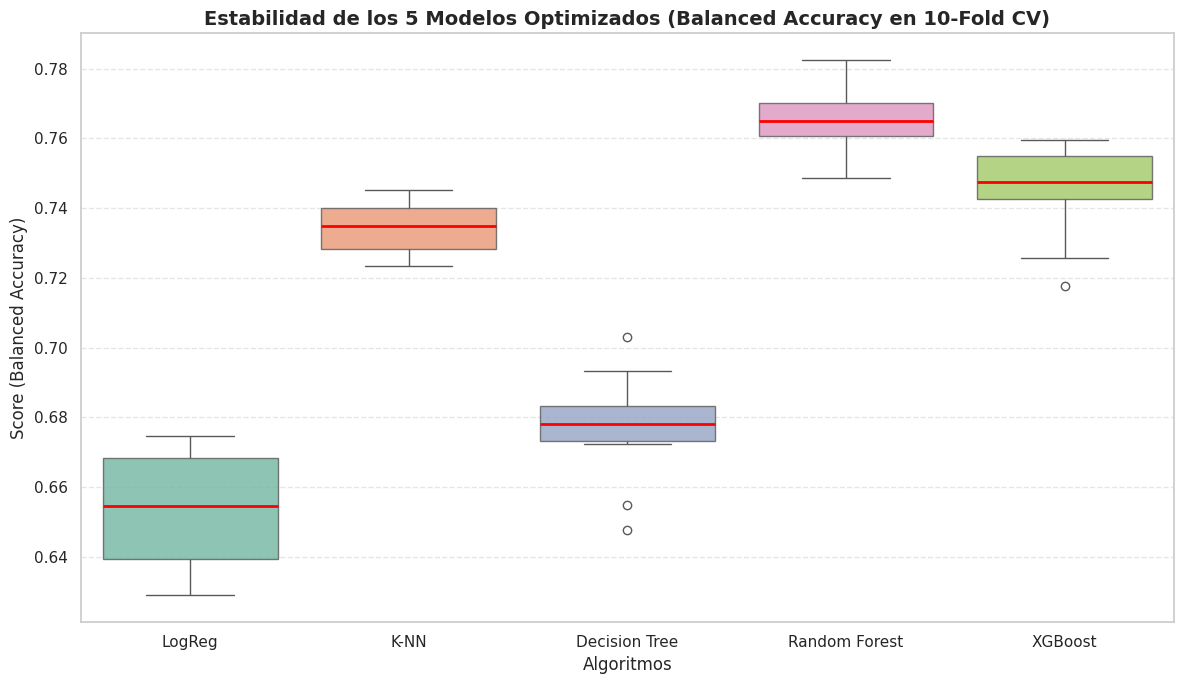

In [17]:
# 3.2 BOXPLOT DE ESTABILIDAD
import matplotlib.pyplot as plt
import seaborn as sns

# Transformación de los resultados de CV a DataFrame
df_resultados_cv = pd.DataFrame(resultados_cv_dict)

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_resultados_cv, palette="Set2", boxprops=dict(alpha=0.8),
            medianprops=dict(color='red', linewidth=2))

plt.title('Estabilidad de los 5 Modelos Optimizados (Balanced Accuracy en 10-Fold CV)', fontsize=14, fontweight='bold')
plt.ylabel('Score (Balanced Accuracy)', fontsize=12)
plt.xlabel('Algoritmos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Evaluación Definitiva en el Conjunto de Prueba (Test Puro)

Una vez obtenidas las arquitecturas óptimas (hiperparámetros) y verificada su estabilidad, se procede a evaluar los 5 modelos por **primera y única vez** sobre el conjunto de datos de prueba (`X_test` e `y_test`).

Este conjunto se mantuvo rigurosamente aislado durante todo el proceso de balanceo y optimización para simular el comportamiento real del sistema predictivo ante datos completamente nuevos. Debido a la naturaleza clínica del problema (riesgo de anemia), prestaremos especial atención a la métrica **Recall**, además del **Accuracy** y el **Área Bajo la Curva (AUC)**.

In [18]:
# Lista para consolidar las métricas de rendimiento en prueba
consolidado_metricas = []

print("EVALUACIÓN DE MODELOS OPTIMIZADOS EN DATA DE TEST (AISLADA)\n")

for nombre, info in mejores_modelos.items():
    modelo_final = info['best_estimator']

    # Generación de predicciones binarias sobre X_test
    y_pred = modelo_final.predict(X_test)

    # Generación de probabilidades para el cálculo del AUC
    if hasattr(modelo_final, "predict_proba"):
        y_prob = modelo_final.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred # Respaldo por si algún modelo no soporta predict_proba

    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    consolidado_metricas.append({
        'Método / Algoritmo': nombre,
        'Hiperparámetros Óptimos': str(info['best_params']),
        'Tiempo (s)': info['tiempo_segundos'],
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4),
        'AUC-ROC': round(auc_score, 4)
    })

# Construcción y despliegue del Cuadro Resumen
df_cuadro_resumen = pd.DataFrame(consolidado_metricas)
df_cuadro_resumen.set_index('Método / Algoritmo', inplace=True)

# Mostramos la tabla formateada
display(df_cuadro_resumen)

EVALUACIÓN DE MODELOS OPTIMIZADOS EN DATA DE TEST (AISLADA)



,Hiperparámetros Óptimos,Tiempo (s),Accuracy,Recall,AUC-ROC
Método / Algoritmo,,,,,
LogReg,"{'C': 10, 'max_iter': 500}",10.40,0.6529,0.6429,0.7092
K-NN,"{'n_neighbors': 5, 'weights': 'distance'}",9.16,0.5843,0.5931,0.6181
Decision Tree,"{'max_depth': 10, 'min_samples_split': 2}",9.98,0.6346,0.5515,0.6425
Random Forest,"{'max_depth': None, 'n_estimators': 50}",68.38,0.6658,0.4742,0.6753
XGBoost,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",73.86,0.6730,0.4678,0.6843


# 5. Conclusiones Generales de la Experimentación

La presente experimentación validó exitosamente la viabilidad de aplicar algoritmos de Machine Learning para la detección del riesgo de anemia infantil utilizando factores sociodemográficos y de vivienda (ENDES 2023), prescindiendo de pruebas sanguíneas invasivas. A partir de los resultados empíricos, concluimos:

1. **Estado del Arte Validado:** El algoritmo avanzado XGBoost logró el mayor nivel de discriminación general con un **Accuracy del 67.30%**. Este resultado valida y replica matemáticamente el estado del arte internacional documentado para modelos entrenados con encuestas demográficas (por ejemplo, el 68.53% reportado por Khan et al. en Bangladesh).
2. **Trade-Off Médico:** Se evidenció un compromiso clínico crucial en los modelos. Mientras que los ensambles basados en árboles priorizan la exactitud global siendo más conservadores, el modelo lineal probabilístico (**Regresión Logística **) demostró ser una herramienta de tamizaje preventivo superior. Al obtener el mayor **Recall (0.6429)** y **AUC (0.7092)**, logra minimizar los falsos negativos, lo cual es éticamente indispensable para evitar que infantes vulnerables queden fuera del sistema de atención.
3. **Eficiencia y Viabilidad:** El proceso de búsqueda de hiperparámetros (GridSearchCV) y el entrenamiento demostraron ser computacionalmente eficientes (tiempos de optimización de entre 9 y 75 segundos), confirmando la viabilidad de desplegar estas soluciones tecnológicas en entornos de salud pública a nivel nacional.